In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load the results CSV
csv_path = "/export/scratch/mickler/boa_models/test/runs/109_test___limit_test_batches-20__from_checkpoint___export_scratch_mklockow_boa_data_qmugs_pyscf_data__test-1___export_scratch_mklockow_boa_data_qmugs_pyscf_datasplits.json__qm9_pyscf_small_from_/expo/tensorboard/version_0/results.csv"

df = pd.read_csv(csv_path)

print(f"Loaded data with {len(df)} rows")
print(f"\nColumns (keys):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print(f"\nFirst few rows:")
df.head()

Loaded data with 17 rows

Columns (keys):
  1. dataset_idx
  2. nmape
  3. num_atoms
  4. num_electrons
  5. time

First few rows:


,dataset_idx,nmape,num_atoms,num_electrons,time
0,0,1.748091,194,730,57.828029
1,0,0.429404,37,146,5.882897
2,0,1.354786,175,684,38.499475
3,0,1.354826,111,428,17.585359
4,0,0.979136,117,452,19.539396


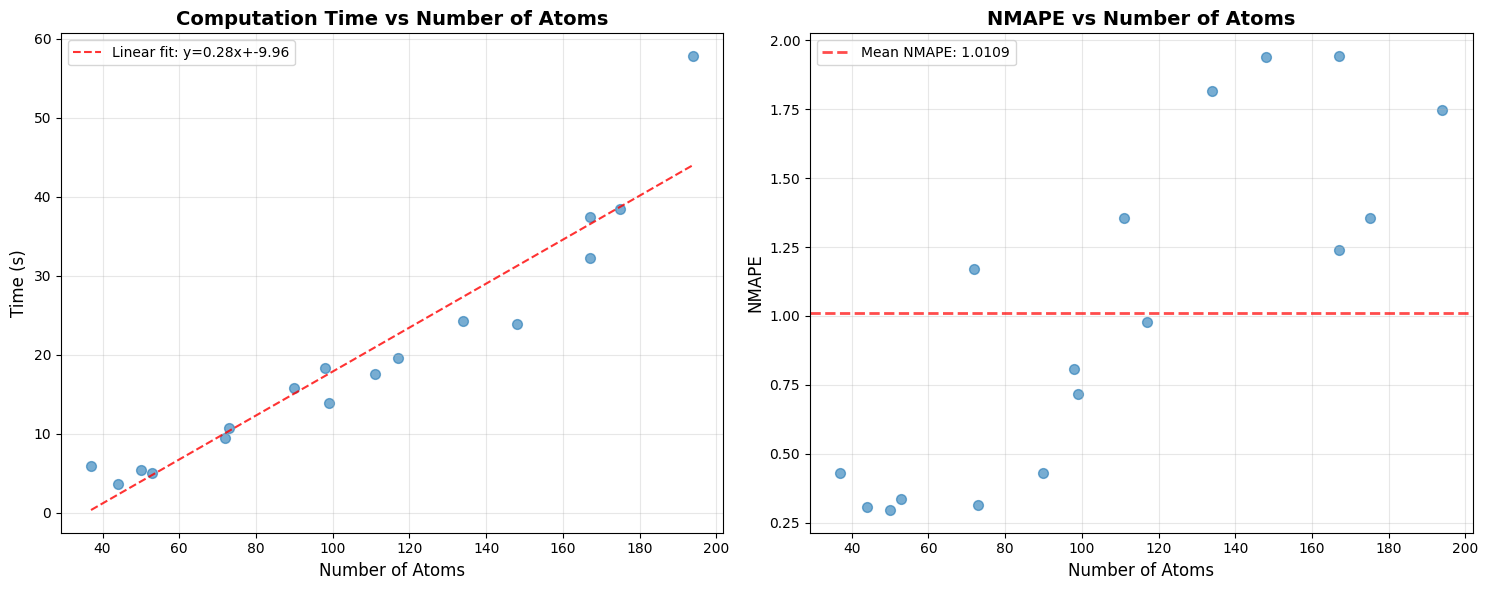


Statistics:
Time:
  Mean: 19.9887 s
  Median: 17.5854 s
  Min: 3.6707 s
  Max: 57.8280 s

NMAPE:
  Mean: 1.010914
  Median: 0.979136
  Min: 0.296258
  Max: 1.942760

Number of Atoms:
  Mean: 107.6
  Median: 99.0
  Min: 37
  Max: 194


In [2]:
import matplotlib.pyplot as plt

# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Time vs num_atoms
ax = axes[0]
ax.scatter(df['num_atoms'], df['time'], alpha=0.6, s=50)
ax.set_xlabel('Number of Atoms', fontsize=12)
ax.set_ylabel('Time (s)', fontsize=12)
ax.set_title('Computation Time vs Number of Atoms', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['num_atoms'], df['time'], 1)
p = np.poly1d(z)
ax.plot(df['num_atoms'].sort_values(), p(df['num_atoms'].sort_values()), 
        "r--", alpha=0.8, label=f'Linear fit: y={z[0]:.2f}x+{z[1]:.2f}')
ax.legend()

# Plot 2: NMAPE vs num_atoms
ax = axes[1]
ax.scatter(df['num_atoms'], df['nmape'], alpha=0.6, s=50)
ax.set_xlabel('Number of Atoms', fontsize=12)
ax.set_ylabel('NMAPE', fontsize=12)
ax.set_title('NMAPE vs Number of Atoms', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add horizontal line for mean NMAPE
mean_nmape = df['nmape'].mean()
ax.axhline(mean_nmape, color='red', linestyle='--', linewidth=2, 
           alpha=0.7, label=f'Mean NMAPE: {mean_nmape:.4f}')
ax.legend()

plt.tight_layout()
plt.show()

# Print statistics
print("\nStatistics:")
print(f"Time:")
print(f"  Mean: {df['time'].mean():.4f} s")
print(f"  Median: {df['time'].median():.4f} s")
print(f"  Min: {df['time'].min():.4f} s")
print(f"  Max: {df['time'].max():.4f} s")

print(f"\nNMAPE:")
print(f"  Mean: {df['nmape'].mean():.6f}")
print(f"  Median: {df['nmape'].median():.6f}")
print(f"  Min: {df['nmape'].min():.6f}")
print(f"  Max: {df['nmape'].max():.6f}")

print(f"\nNumber of Atoms:")
print(f"  Mean: {df['num_atoms'].mean():.1f}")
print(f"  Median: {df['num_atoms'].median():.1f}")
print(f"  Min: {df['num_atoms'].min()}")
print(f"  Max: {df['num_atoms'].max()}")